# 1. Dataset Cleaning
We verify images first to ensure no corrupted files interfere with the generators.

This section prepares the dataset by organizing image folders, removing corrupted or invalid files, and ensuring that the data is ready for training and evaluation. Proper cleaning improves model accuracy and reduces training errors.

This code cell mounts Google Drive, defines source and destination paths for the dataset, and includes a function (`clean_and_copy`) to verify image integrity and copy valid images to a new directory. Finally, it runs the cleaning process for both training and testing datasets.

In [ ]:
from google.colab import drive
import os
import shutil
from PIL import Image

# 1. MOUNT GOOGLE DRIVE
drive.mount('/content/drive')

# 2. DEFINE SOURCE PATHS (From your Drive)
base_source_dir = '/content/drive/MyDrive/AI and Machine Learning/Scene Classification'
train_src = os.path.join(base_source_dir, 'train')
test_src = os.path.join(base_source_dir, 'test')

# 3. DEFINE DESTINATION PATHS (Local Colab runtime storage)
clean_train_dir = '/content/clean_data/train'
clean_test_dir = '/content/clean_data/test'

def clean_and_copy(src, dst):
    """Verifies images and copies only valid ones to a new directory."""
    if not os.path.exists(dst):
        os.makedirs(dst)

    total, kept = 0, 0

    # Iterate through classes (sea, mountain, etc.)
    for cls in os.listdir(src):
        s_path = os.path.join(src, cls)
        d_path = os.path.join(dst, cls)

        if not os.path.isdir(s_path): continue
        if not os.path.exists(d_path): os.makedirs(d_path)

        for f in os.listdir(s_path):
            total += 1
            f_path = os.path.join(s_path, f)
            try:
                with Image.open(f_path) as img:
                    img.verify() # Check for corruption
                # Re-open because verify() closes the file handle
                shutil.copy2(f_path, os.path.join(d_path, f))
                kept += 1
            except Exception:
                # This skips corrupted files
                pass

    print(f'Processed {src}: Kept {kept}/{total} valid images.')

# Run the cleaning process
clean_and_copy(train_src, clean_train_dir)
clean_and_copy(test_src, clean_test_dir)

Mounted at /content/drive
Processed /content/drive/MyDrive/AI and Machine Learning/Scene Classification/train: Kept 13992/14034 valid images.
Processed /content/drive/MyDrive/AI and Machine Learning/Scene Classification/test: Kept 3000/3000 valid images.


# 2. Data Understanding
Visualizing class distribution and samples from the cleaned dataset.

In this section, the dataset is explored through visualizations and statistical analysis. The goal is to understand class distribution, image dimensions, and overall dataset characteristics before model development.

This code cell imports `matplotlib.pyplot` for plotting. It calculates the number of images in each class within the cleaned training directory and then visualizes this class distribution using a bar chart. It also prints the total number of cleaned training images.

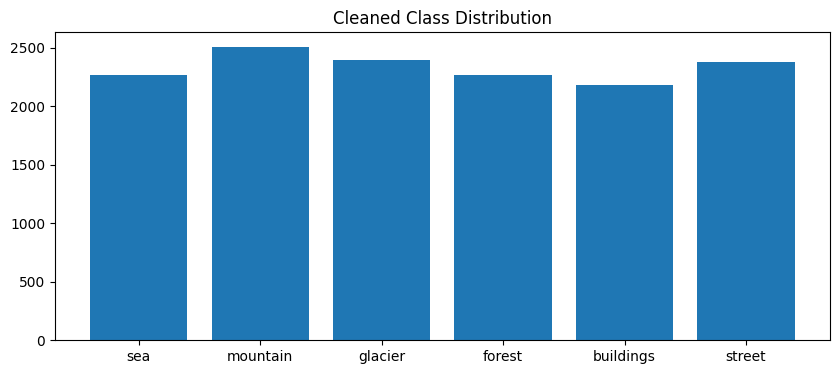

Total Clean Training Images: 13992


In [ ]:
import matplotlib.pyplot as plt

classes = os.listdir(clean_train_dir)
counts = {c: len(os.listdir(os.path.join(clean_train_dir, c))) for c in classes}

plt.figure(figsize=(10, 4))
plt.bar(counts.keys(), counts.values())
plt.title("Cleaned Class Distribution")
plt.show()

print(f"Total Clean Training Images: {sum(counts.values())}")

This code cell imports `numpy` and then iterates through each class to display a sample image from the `clean_train_dir`. It visualizes these sample images in a grid, along with their respective class names and image counts.

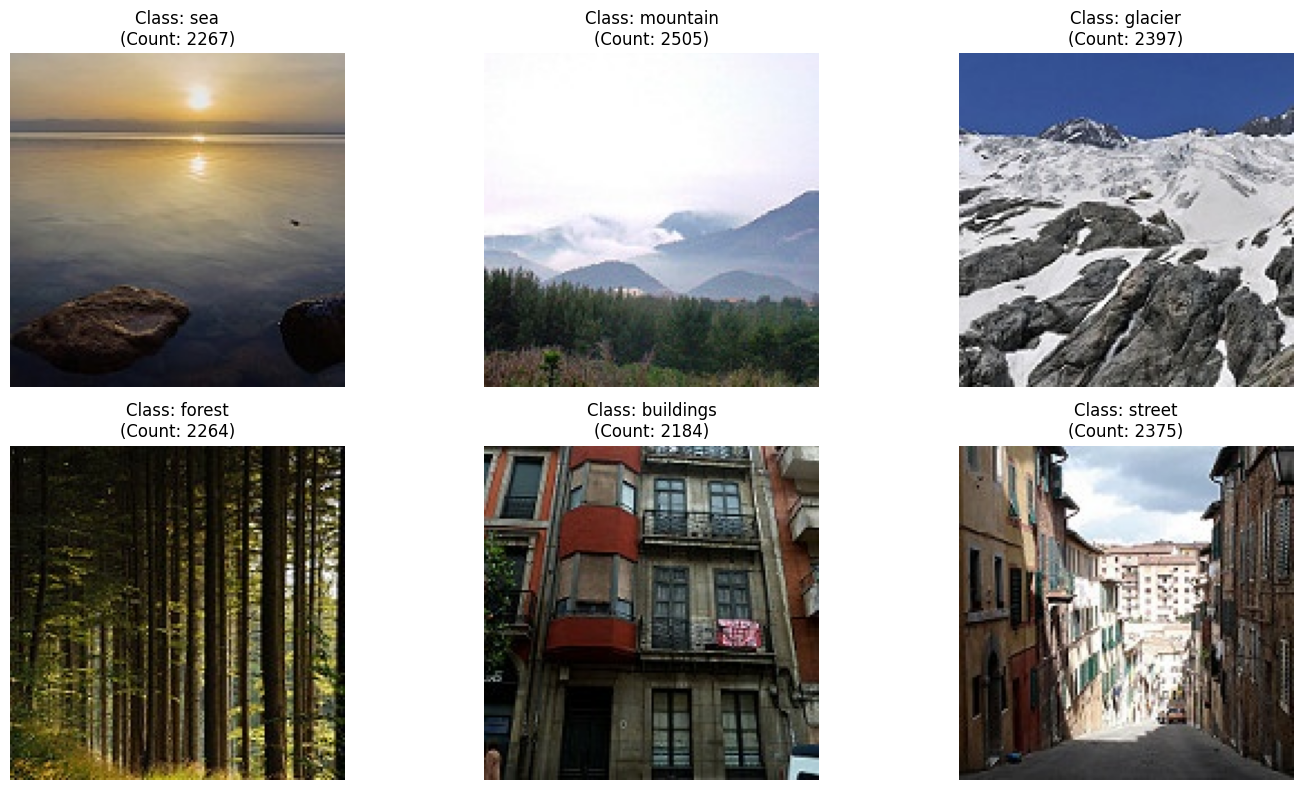

In [ ]:
import numpy as np

# Visualize sample images from each class
plt.figure(figsize=(15, 8))
for i, cls in enumerate(classes):
    cls_path = os.path.join(clean_train_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {cls}\n(Count: {counts[cls]})")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 3. Data Generators (128x128)
Creating standardized generators for the custom CNN models.

Image data generators are used to preprocess and augment the dataset. Images are resized to 128x128 pixels, normalized, and augmented with transformations such as rotation, zoom, and flipping to improve model generalization.

This cell initializes `ImageDataGenerator` from `tensorflow.keras.preprocessing.image` to create data generators for the models. It defines image resizing to 128x128 pixels and includes data augmentation (rotation, horizontal flip) for the training set. Separate generators are created for training, validation, and test sets, with appropriate scaling.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

size_128 = (128, 128)

train_datagen_128 = ImageDataGenerator(rescale=1./255, validation_split=0.2, rotation_range=20, horizontal_flip=True)
val_datagen_128 = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen_128 = train_datagen_128.flow_from_directory(clean_train_dir, target_size=size_128, batch_size=32, subset='training')
val_gen_128 = val_datagen_128.flow_from_directory(clean_train_dir, target_size=size_128, batch_size=32, subset='validation')
test_gen_128 = ImageDataGenerator(rescale=1./255).flow_from_directory(clean_test_dir, target_size=size_128, batch_size=32, shuffle=False)

Found 11196 images belonging to 6 classes.
Found 2796 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


# 4. Baseline CNN (3 Conv + 3 Dense)
Strictly following the requirement: 3 Conv layers and 3 Dense layers before the output.

A baseline Convolutional Neural Network (CNN) model is created using three convolutional layers and three dense layers. This model serves as the initial benchmark for evaluating classification performance.

This code defines and trains a baseline Convolutional Neural Network (CNN) model using `tensorflow.keras`. The model consists of three `Conv2D` layers followed by `MaxPooling2D` layers, a `Flatten` layer, and three `Dense` layers before the final `softmax` output layer. It is compiled with the Adam optimizer and trained for 10 epochs.

In [ ]:
import time
from tensorflow.keras import layers, models

model_baseline = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(classes), activation='softmax')
])

model_baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
start = time.time()
hist_base = model_baseline.fit(train_gen_128, validation_data=val_gen_128, epochs=10)
base_time = time.time() - start
print(f"Baseline Training Time: {base_time:.2f}s")

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 71s 184ms/step - accuracy: 0.5564 - loss: 1.1045 - val_accuracy: 0.6345 - val_loss: 0.9166
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 161ms/step - accuracy: 0.6985 - loss: 0.7955 - val_accuracy: 0.7586 - val_loss: 0.6847
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 160ms/step - accuracy: 0.7492 - loss: 0.6850 - val_accuracy: 0.7836 - val_loss: 0.5949
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 159ms/step - accuracy: 0.7800 - loss: 0.6035 - val_accuracy: 0.7979 - val_loss: 0.5376
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 158ms/step - accuracy: 0.8033 - loss: 0.5302 - val_accuracy: 0.8104 - val_loss: 0.5395
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 156ms/step - accuracy: 0.8233 - loss: 0.4948 - val_accuracy: 0.8197 - val_loss: 0.5134
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 159ms/step - accuracy: 0.8300 - loss: 0.4662 - val_accuracy: 0.7829 - val_loss: 0.5934
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 157ms/step - accuracy: 0.8491 - loss: 0

# 5. Baseline Evaluation
Calculating Precision, Recall, F1-score and visualizing inference.

The baseline CNN model is evaluated using performance metrics such as accuracy, loss, confusion matrix, and classification reports to measure how well the model performs on unseen data.

This code cell evaluates the `model_baseline` by making predictions on the test set. It then uses `sklearn.metrics.classification_report` to print precision, recall, and F1-score for each class. Finally, it plots the training and validation loss curves over epochs to visualize the model's performance during training.

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step
              precision    recall  f1-score   support

         sea       0.78      0.85      0.82       437
    mountain       0.97      0.96      0.96       474
     glacier       0.80      0.83      0.82       553
      forest       0.82      0.79      0.80       525
   buildings       0.87      0.79      0.83       510
      street       0.85      0.87      0.86       501

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



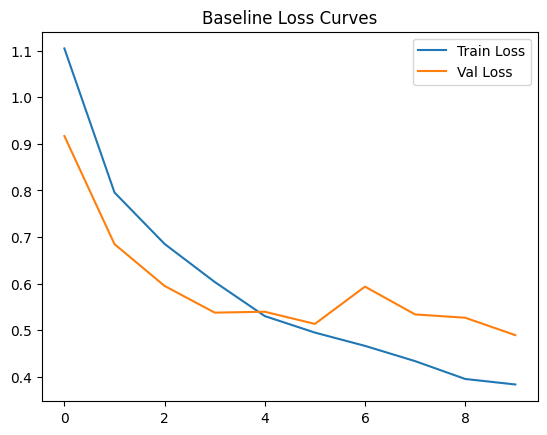

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Metrics
preds_base = model_baseline.predict(test_gen_128)
y_pred_base = np.argmax(preds_base, axis=1)
print(classification_report(test_gen_128.classes, y_pred_base, target_names=classes))

# Plots
plt.plot(hist_base.history['loss'], label='Train Loss')
plt.plot(hist_base.history['val_loss'], label='Val Loss')
plt.title('Baseline Loss Curves')
plt.legend()
plt.show()

# 6. Deeper CNN with Regularization
This model has double the layers of the baseline and includes BatchNorm and Dropout.

A deeper CNN architecture is implemented with regularization techniques such as dropout and batch normalization. These methods help reduce overfitting and improve model generalization.

This cell defines a deeper CNN model compared to the baseline, incorporating additional convolutional layers, `BatchNormalization` for faster and more stable training, and `Dropout` layers to prevent overfitting in the dense layers. The model is compiled with the Adam optimizer and trained for 10 epochs.

In [ ]:
model_deeper = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'), layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'), layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'), layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'), layers.Dropout(0.5),
    layers.Dense(256, activation='relu'), layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(classes), activation='softmax')
])

model_deeper.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
start = time.time()
hist_deep = model_deeper.fit(train_gen_128, validation_data=val_gen_128, epochs=10)
deep_time = time.time() - start
print(f"Deeper Model Training Time: {deep_time:.2f}s")

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 82s 198ms/step - accuracy: 0.4050 - loss: 1.6535 - val_accuracy: 0.4324 - val_loss: 1.4185
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 167ms/step - accuracy: 0.5645 - loss: 1.0902 - val_accuracy: 0.6316 - val_loss: 0.9864
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 167ms/step - accuracy: 0.6297 - loss: 0.9652 - val_accuracy: 0.5655 - val_loss: 1.1445
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 59s 169ms/step - accuracy: 0.6722 - loss: 0.8715 - val_accuracy: 0.4778 - val_loss: 1.5465
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 165ms/step - accuracy: 0.7153 - loss: 0.7820 - val_accuracy: 0.6277 - val_loss: 1.1296
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.7447 - loss: 0.7257 - val_accuracy: 0.7300 - val_loss: 0.7442
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 166ms/step - accuracy: 0.7598 - loss: 0.6810 - val_accuracy: 0.7242 - val_loss: 0.7209
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 59s 168ms/step - accuracy: 0.7795 - loss: 0

# 7. Optimizer Comparison: SGD vs Adam
Comparing convergence speed and performance.

This section compares the performance of different optimization algorithms, specifically SGD and Adam, to determine which optimizer provides better convergence and accuracy for the CNN model.

This code cell compares the performance of the SGD and Adam optimizers on a simplified CNN model. It defines a `build_comp_model` function, then trains two instances of this model: one with `SGD` and another with `Adam`. After training, it plots the training accuracy for both models over 5 epochs to show their convergence behavior.

Training with SGD...
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 60s 166ms/step - accuracy: 0.4783 - loss: 1.3290 - val_accuracy: 0.5805 - val_loss: 1.1001
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 157ms/step - accuracy: 0.5899 - loss: 1.0632 - val_accuracy: 0.6044 - val_loss: 1.0408
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 155ms/step - accuracy: 0.6363 - loss: 0.9672 - val_accuracy: 0.6363 - val_loss: 0.9573
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 159ms/step - accuracy: 0.6552 - loss: 0.9094 - val_accuracy: 0.6617 - val_loss: 0.9088
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 81s 158ms/step - accuracy: 0.6736 - loss: 0.8723 - val_accuracy: 0.6820 - val_loss: 0.8509

Training with Adam...
Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 58s 161ms/step - accuracy: 0.5938 - loss: 1.1315 - val_accuracy: 0.6452 - val_loss: 0.9820
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 160ms/step - accuracy: 0.7005 - loss: 0.8219 - val_accuracy: 0.6842 - val_loss: 0.9040
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 159

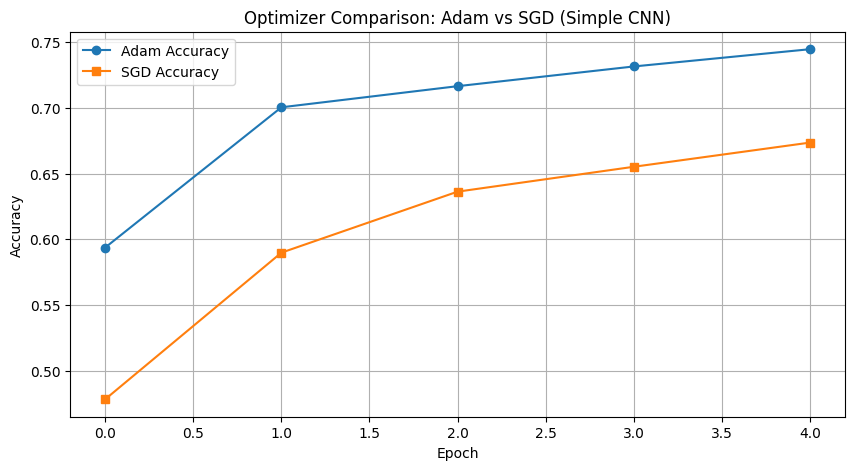

In [ ]:
from tensorflow.keras.optimizers import SGD, Adam

# Define a simple version for comparison to keep training fast
def build_comp_model():
    return models.Sequential([
        layers.Input(shape=(128, 128, 3)),
        layers.Conv2D(32, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(len(classes), activation='softmax')
    ])

# 1. Train with SGD
print("Training with SGD...")
model_sgd = build_comp_model()
model_sgd.compile(optimizer=SGD(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])
hist_sgd = model_sgd.fit(train_gen_128, validation_data=val_gen_128, epochs=5, verbose=1)

# 2. Train with Adam
print("\nTraining with Adam...")
model_adam_comp = build_comp_model()
model_adam_comp.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
hist_adam_comp = model_adam_comp.fit(train_gen_128, validation_data=val_gen_128, epochs=5, verbose=1)

# Plot Comparison
plt.figure(figsize=(10, 5))
plt.plot(hist_adam_comp.history['accuracy'], label='Adam Accuracy', marker='o')
plt.plot(hist_sgd.history['accuracy'], label='SGD Accuracy', marker='s')
plt.title('Optimizer Comparison: Adam vs SGD (Simple CNN)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 8. Ablation Study
Removing Dropout to analyze the impact on overfitting.

An ablation study is conducted to analyze the contribution of different components of the model. Certain layers or techniques are removed to observe their impact on performance.

This cell performs an ablation study by creating a simplified CNN model (`model_ablation`) that intentionally removes the `Dropout` layer present in other models. It compiles and trains this model for 10 epochs, then plots the training and validation accuracy curves. The purpose is to observe the impact of removing dropout on model performance and potential overfitting.

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 60s 163ms/step - accuracy: 0.5787 - loss: 1.6668 - val_accuracy: 0.6656 - val_loss: 0.9196
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 158ms/step - accuracy: 0.6851 - loss: 0.8426 - val_accuracy: 0.7028 - val_loss: 0.8356
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 159ms/step - accuracy: 0.7158 - loss: 0.7763 - val_accuracy: 0.7210 - val_loss: 0.7728
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 157ms/step - accuracy: 0.7410 - loss: 0.7118 - val_accuracy: 0.7378 - val_loss: 0.7210
Epoch 5/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 159ms/step - accuracy: 0.7587 - loss: 0.6727 - val_accuracy: 0.7493 - val_loss: 0.7059
Epoch 6/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 161ms/step - accuracy: 0.7700 - loss: 0.6317 - val_accuracy: 0.7589 - val_loss: 0.7242
Epoch 7/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 161ms/step - accuracy: 0.7797 - loss: 0.6057 - val_accuracy: 0.7672 - val_loss: 0.6785
Epoch 8/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 56s 161ms/step - accuracy: 0.7929 - loss: 0

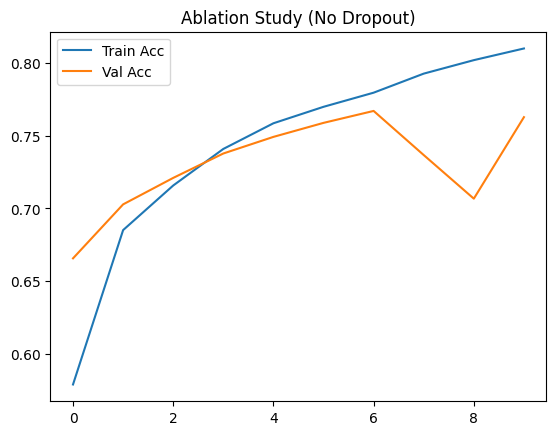

In [ ]:
model_ablation = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'), layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'), # Dropout removed here
    layers.Dense(len(classes), activation='softmax')
])

model_ablation.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_ablation = model_ablation.fit(train_gen_128, validation_data=val_gen_128, epochs=10)

# Analyze gap between train/val accuracy
plt.plot(hist_ablation.history['accuracy'], label='Train Acc')
plt.plot(hist_ablation.history['val_accuracy'], label='Val Acc')
plt.title('Ablation Study (No Dropout)')
plt.legend()
plt.show()

# 9. Part B: Transfer Learning (MobileNetV2)
Following Section 2.6, we use a pre-trained model on ImageNet. This requires resizing images to 224x224.

Transfer learning is applied using the MobileNetV2 pretrained model. This approach leverages previously learned features from large datasets to improve classification accuracy and reduce training time.

This cell prepares data generators for transfer learning by resizing images to 224x224 pixels, which is the input size typically expected by pre-trained models like MobileNetV2. It creates new `train_gen_224`, `val_gen_224`, and `test_gen_224` instances using the `ImageDataGenerator`.

In [ ]:
size_224 = (224, 224)

# New generators for Transfer Learning
train_gen_224 = train_datagen_128.flow_from_directory(clean_train_dir, target_size=size_224, batch_size=32, subset='training')
val_gen_224 = val_datagen_128.flow_from_directory(clean_train_dir, target_size=size_224, batch_size=32, subset='validation')
test_gen_224 = ImageDataGenerator(rescale=1./255).flow_from_directory(clean_test_dir, target_size=size_224, batch_size=32, shuffle=False)

Found 11196 images belonging to 6 classes.
Found 2796 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


## 9.1 Feature Extraction
Freezing the base model and training only the custom classifier.

The pretrained MobileNetV2 model is used as a fixed feature extractor. Only the classification head is trained while the base model weights remain frozen.

This code cell implements the feature extraction phase of transfer learning using MobileNetV2. It loads `MobileNetV2` pretrained on ImageNet, sets its layers to `non-trainable` (freezing them), and adds a new classification head with `GlobalAveragePooling2D`, `Dense` layers, and `Dropout`. The model is compiled with Adam and trained for 5 epochs on the new classification head.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
import time

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(classes), activation='softmax')
])

model_tl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
start_tl_fe = time.time()
history_tl = model_tl.fit(train_gen_224, validation_data=val_gen_224, epochs=5)
end_tl_fe = time.time()
trans_learn_fe_time = end_tl_fe - start_tl_fe
print(f"Transfer Learning Feature Extraction Time: {trans_learn_fe_time:.2f}s")

Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 157s 420ms/step - accuracy: 0.8211 - loss: 0.4769 - val_accuracy: 0.9027 - val_loss: 0.2778
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 134s 383ms/step - accuracy: 0.8700 - loss: 0.3519 - val_accuracy: 0.8995 - val_loss: 0.2777
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 134s 384ms/step - accuracy: 0.8804 - loss: 0.3212 - val_accuracy: 0.9020 - val_loss: 0.2688
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 134s 383ms/step - accuracy: 0.8925 - loss: 0.2974 - val_accuracy: 0.9063 - val_loss: 0.2529
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 136s 388ms/step - accuracy: 0.8889 - loss: 0.2984 - val_accuracy: 0.9081 - val_loss: 0.2478
Transfer Learning Feature Extraction Time: 696.52s


## 9.2 Fine-Tuning
Unfreezing the top layers of the base model with a lower learning rate.

Fine-tuning is performed by unfreezing selected layers of MobileNetV2 and retraining them on the target dataset. This helps adapt pretrained features to the specific classification task.

This code cell performs fine-tuning on the `MobileNetV2` model. It unfreezes the `base_model` but specifically freezes layers up to index 100 to selectively retrain only the later layers. The model is then recompiled with a very small learning rate (1e-5) using the Adam optimizer and trained for an additional 5 epochs, allowing fine adjustments to the pre-trained weights.

In [ ]:
import time
from tensorflow.keras.optimizers import Adam

base_model.trainable = True
# Freeze up to layer 100
for layer in base_model.layers[:100]:
    layer.trainable = False

model_tl.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
start_tl_ft = time.time()
history_finetune = model_tl.fit(train_gen_224, validation_data=val_gen_224, epochs=5)
end_tl_ft = time.time()
trans_learn_ft_time = end_tl_ft - start_tl_ft
print(f"Transfer Learning Fine-tuning Time: {trans_learn_ft_time:.2f}s")
total_trans_learn_time = trans_learn_fe_time + trans_learn_ft_time

Epoch 1/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 180s 456ms/step - accuracy: 0.8091 - loss: 0.5187 - val_accuracy: 0.9052 - val_loss: 0.2763
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 136s 390ms/step - accuracy: 0.8667 - loss: 0.3683 - val_accuracy: 0.9038 - val_loss: 0.2881
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 137s 392ms/step - accuracy: 0.8842 - loss: 0.3273 - val_accuracy: 0.9059 - val_loss: 0.2918
Epoch 4/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 137s 393ms/step - accuracy: 0.8903 - loss: 0.2960 - val_accuracy: 0.9099 - val_loss: 0.2673
Epoch 5/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 140s 400ms/step - accuracy: 0.9007 - loss: 0.2729 - val_accuracy: 0.9142 - val_loss: 0.2585
Transfer Learning Fine-tuning Time: 731.49s


# 10. Final Comparative Analysis
Summarizing performance across all requirements (Accuracy, Time, Complexity).

This section summarizes and compares the performance of all implemented models, including the baseline CNN, deeper CNN, optimizer experiments, ablation study, and transfer learning approaches.

This code cell consolidates the evaluation results of the different models trained. It creates a Pandas DataFrame to compare the 'Baseline', 'Deeper', and 'Transfer Learning' models based on their test accuracy and total training time. The `evaluate` method is used to get the test accuracy for each model, and the results are displayed in a table.

In [ ]:
import pandas as pd

# Assuming evaluation metrics were stored
data = {
    'Model': ['Baseline', 'Deeper', 'Transfer Learning'],
    'Test Accuracy': [
        model_baseline.evaluate(test_gen_128, verbose=0)[1],
        model_deeper.evaluate(test_gen_128, verbose=0)[1],
        model_tl.evaluate(test_gen_224, verbose=0)[1]
    ],
    'Training Time': [f'{base_time:.1f}s', f'{deep_time:.1f}s', f'{total_trans_learn_time:.1f}s']
}

df_results = pd.DataFrame(data)
display(df_results)

print("Hardware Acceleration Used: GPU (Google Colab)")

,Model,Test Accuracy,Training Time
0,Baseline,0.847000,597.4s
1,Deeper,0.756667,632.8s
2,Transfer Learning,0.911000,1428.0s


Hardware Acceleration Used: GPU (Google Colab)
